In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)


In [3]:
query = session.query(Feedback).join(Round).filter(
        Feedback.key_name=='cargo_shuttle_order',
        Round.start_datetime >= datetime(2023, 7, 1))

In [168]:
df = pd.read_sql_query(
    query.statement,
    session.connection()
)
df['month'] = df.datetime.dt.month
df['day'] = df.datetime.dt.day
df['year'] = df.datetime.dt.year

In [36]:
from collections import namedtuple
Shuttle = namedtuple('Shuttle', ['path', 'names', 'intro_date'])
chop_name = lambda shuttle: shuttle.path.split('/')[-1]

In [288]:
shuttles = [
    Shuttle('/datum/map_template/shuttle/emergency/bar', ["Emergency Escape Bar", "NTV Charon (Bar)"], date(2016, 7, 28)),
    # Shuttle('/datum/map_template/shuttle/emergency/cyb', ["Emergency shuttle (Cyberiad)"], date(2016, 8, 3)),
    Shuttle('/datum/map_template/shuttle/emergency/dept', ["NTV Charon (Departmental)", "Emergency shuttle (department)"], date(2017, 6, 8)),
    Shuttle('/datum/map_template/shuttle/emergency/military', ["NTV Charon (Militarized)", "Emergency shuttle (military)"], date(2017, 7, 26)),
    Shuttle('/datum/map_template/shuttle/emergency/clown', ["NCV Snappop(tm)", "Snappop(tm)"], date(2016, 7, 28)),
    Shuttle('/datum/map_template/shuttle/emergency/cramped', ["Secure Transport Vessel 5 (STV5)"], date(2016, 7, 28)),
   # Shuttle('/datum/map_template/shuttle/emergency/meta', ["Emergency shuttle (Metastation)"], date(2016, 7, 28)),
   # Shuttle('/datum/map_template/shuttle/emergency/narnar', ["Shuttle 667"], date(2016, 7, 28)),
    Shuttle('/datum/map_template/shuttle/emergency/old', ["Retired Station shuttle."], date(2016, 9, 22)),
    #Shuttle('/datum/map_template/shuttle/emergency/jungle', ["Emergency shuttle JUNG-13"], date(2022, 11, 10)),
    Shuttle('/datum/map_template/shuttle/emergency/raven', ["NSV Raven", "CentCom Raven Cruiser"], date(2024, 3, 21)),
    Shuttle('/datum/map_template/shuttle/emergency/shadow', ["NRTV Shadow", "The NTSS Shadow"], date(2024, 4, 26)),
    Shuttle('/datum/map_template/shuttle/emergency/lance', ["NAV Lance", "The Lance Crew Evacuation System"], date(2024, 5, 15)),
]

all_shuttle_names = {name for shuttle in shuttles for name in shuttle.names}

def check_for_shuttle_names(d):
    for k, v in d['data'].items():
        if k in all_shuttle_names:
            return True
    return False


In [169]:
def json_to_series(text):
    keys = []
    values = []
    results = [x for x in zip(*[(k, v) for k, v in text['data'].items() if k in all_shuttle_names])]
    if results:
        keys, values = results
    return pd.Series(values, index=keys)
df = pd.concat([df, df['json'].apply(json_to_series)], axis=1)

In [171]:
checked_df = df[df['json'].map(check_for_shuttle_names)]

In [172]:
checked_df

,id,datetime,round_id,key_name,key_type,version,json,month,day,year,...,Emergency Escape Bar,Retired Station shuttle.,CentCom Raven Cruiser,The NTSS Shadow,The Lance Crew Evacuation System,NSV Raven,NTV Charon (Departmental),NTV Charon (Militarized),NRTV Shadow,NTV Charon (Bar)
2858,359047,2024-03-10 22:54:12,39500,cargo_shuttle_order,tally,1,"{'data': {'DNA Vault Parts': 1, 'DNA Vault Sam...",3,10,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2861,358919,2024-03-11 05:57:43,39503,cargo_shuttle_order,tally,1,{'data': {'IK-30 Security Laser Rifle Crate': ...,3,11,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2867,358639,2024-03-11 18:35:27,39510,cargo_shuttle_order,tally,1,"{'data': {'Machine Prototype Crate': 1, 'Disab...",3,11,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2868,359382,2024-03-11 20:56:35,39511,cargo_shuttle_order,tally,1,"{'data': {'Bluespace Harvester Parts': 1, 'Col...",3,11,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2869,359336,2024-03-11 23:16:31,39512,cargo_shuttle_order,tally,1,"{'data': {'Exotic Seeds Crate': 1, 'Blood Pack...",3,11,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4573,480936,2024-08-06 15:08:59,41351,cargo_shuttle_order,tally,1,"{'data': {'DNA Vault Samplers': 3, 'DNA Vault ...",8,6,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4577,480700,2024-08-07 00:20:41,41355,cargo_shuttle_order,tally,1,"{'data': {'DNA Vault Parts': 2, 'DNA Vault Sam...",8,7,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4578,480641,2024-08-07 02:36:00,41356,cargo_shuttle_order,tally,1,"{'data': {'DNA Vault Samplers': 1, 'DNA Vault ...",8,7,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
4582,480431,2024-08-07 11:29:32,41360,cargo_shuttle_order,tally,1,"{'data': {'Imported Vending Machines': 1, 'Shi...",8,7,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN


In [289]:
wanted_columns = all_shuttle_names.union({'month', 'year'})

In [290]:
intersected = checked_df[checked_df.columns.intersection(wanted_columns)]

In [285]:
intersected

,month,year,Emergency shuttle (military),Snappop(tm),Emergency shuttle (department),Secure Transport Vessel 5 (STV5),Emergency Escape Bar,Retired Station shuttle.,CentCom Raven Cruiser,The NTSS Shadow,The Lance Crew Evacuation System,NSV Raven,NTV Charon (Departmental),NTV Charon (Militarized),NRTV Shadow,NTV Charon (Bar)
2858,3,2024,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2861,3,2024,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2867,3,2024,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2868,3,2024,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2869,3,2024,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4573,8,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4577,8,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4578,8,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
4582,8,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN


In [176]:
shuttle

Shuttle(path='/datum/map_template/shuttle/emergency/bar', names=('Emergency Escape Bar', 'NTV Charon (Bar)'), intro_date=datetime.date(2016, 7, 28))

In [291]:
munged = intersected.groupby(['month', 'year']).sum().astype(int)

In [292]:
final = pd.DataFrame()
for shuttle in shuttles:
    name = chop_name(shuttle)
    names = list()
    for n in shuttle.names:
        if n in munged:
            names.append(n)
    final[name] = munged[names].sum(axis=1)
final = final.reset_index(level=['month', 'year'])
final['dt'] = pd.to_datetime(final.year.astype(str) + final.month.astype(str), format='%Y%m')

In [293]:
final

,month,year,bar,dept,military,clown,cramped,old,raven,shadow,lance,dt
0,3,2024,13,13,5,11,8,4,20,0,0,2024-03-01
1,4,2024,15,10,6,1,9,3,25,3,0,2024-04-01
2,5,2024,17,6,1,1,9,4,38,18,10,2024-05-01
3,6,2024,10,13,1,0,3,4,22,20,1,2024-06-01
4,7,2024,10,12,6,0,4,2,19,16,0,2024-07-01
5,8,2024,1,3,1,0,4,0,4,2,0,2024-08-01


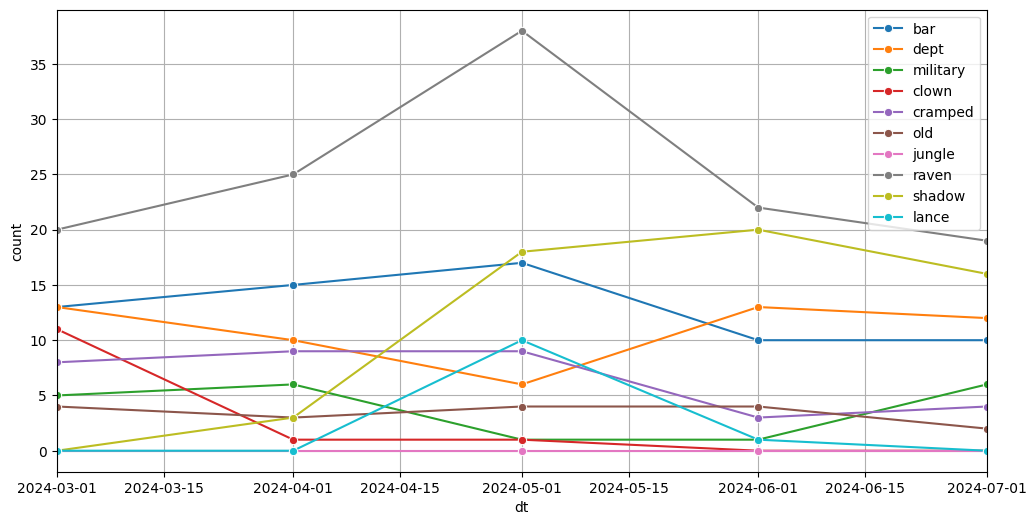

In [274]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
for shuttle in shuttles:
    name = chop_name(shuttle)
    sns.lineplot(data=final, x='dt', y=name, marker='o', label=name)

ax.set(ylabel='count')
plt.grid()
plt.xlim(date(2024, 3, 1), date(2024, 7, 1))
plt.savefig('shuttles.png')

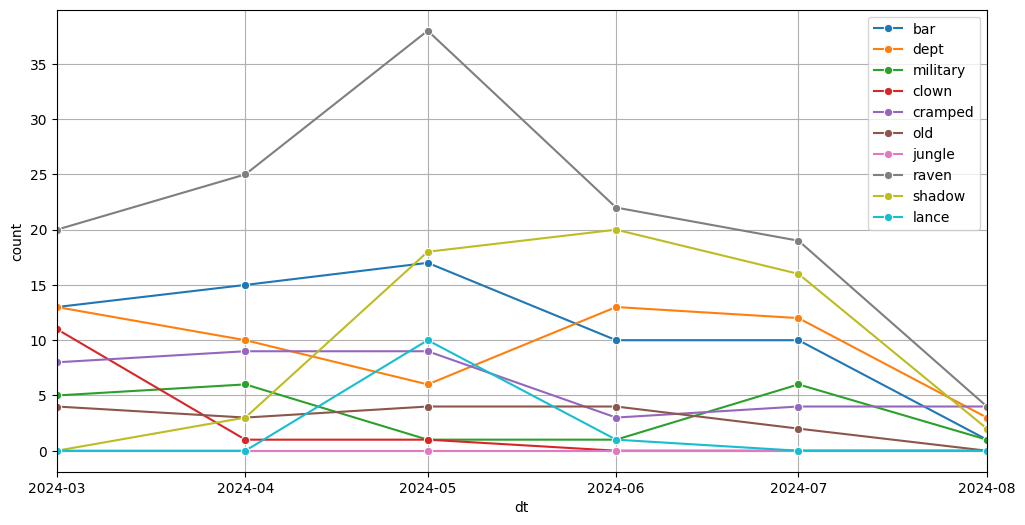

In [279]:

import matplotlib.dates as mdates ## Import required library
months = mdates.MonthLocator(interval=1)  ## 1 month apart & show last date

fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
for shuttle in shuttles:
    name = chop_name(shuttle)
    sns.lineplot(data=final, x='dt', y=name, marker='o', label=name)

ax.set(ylabel='count')
plt.grid()
plt.xlim(date(2024, 3, 1), date(2024, 8, 1))
plt.gca().xaxis.set_major_locator(months) ## Set months as major locator
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.savefig("cargo.png")